In [491]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

In [492]:
class Config:
    #---------------------------------------------------------------------------
    # 1. 기본 백테스팅 환경
    #---------------------------------------------------------------------------

    QUANT_DATA_PATH = "퀀트데이터_260102.csv"
    START_DATE = "2016-01-01"  # 백테스트 시작일
    END_DATE = "2026-01-01"    # 백테스트 종료일
    FEES = 0.00015             # 거래 수수료

    #---------------------------------------------------------------------------
    # 2. 카나리아 (Market Signal) 설정
    #---------------------------------------------------------------------------

    # 카나리아 자산 리스트
    CANARY_ASSETS = ['QQQ', 'SHY', 'LQD', 'HYG']

    # 카나리아 생존 판단 기준 (이동평균선)
    # 예: 200 -> 200일 이평선보다 가격이 높으면 '생존'
    CANARY_MA_PERIOD = 200

    # 리밸런싱 주기 (카나리아 확인 및 자산 교체 주기)
    # 'ME': 매월, 'QE': 분기별, '6ME': 반년
    REBALANCING_FREQ = 'QE'

    #---------------------------------------------------------------------------
    # 3. 자산 배분 비율 (Dynamic Asset Allocation)
    #---------------------------------------------------------------------------

    # 카나리아 생존 마릿수(key)에 따른 [공격자산 : 방어자산] 비중 설정
    # 현재 n=4 기준
    ALLOCATION_RULE = {
        4: {'attack': 1.0, 'defense': 0.0},  # 4마리 생존: 공격 100%
        3: {'attack': 0.75, 'defense': 0.25},
        2: {'attack': 0.50, 'defense': 0.50},
        1: {'attack': 0.25, 'defense': 0.75},
        0: {'attack': 0.0, 'defense': 1.0}   # 전멸: 수비 100%
    }

    #---------------------------------------------------------------------------
    # 4. 공격 자산
    #---------------------------------------------------------------------------

    # 유니버스 설정
    UNIVERSE_INDEX = "KOSPI" # 투자 대상 지수
    MIN_MARKET_CAP = 3000       # 시가총액 하한선 (단위: 억원)

    # 제외 조건 (Filter)
    EXCLUDE_KEYWORDS = ["스팩", "리츠"] # 이름에 포함되면 제외
    EXCLUDE_DEFICIT = True      # 적자 기업 제외 여부 (True/False)
    EXCLUDE_ADMIN = True        # 관리 종목 제외 여부

    COL_MAPPING = {
        'code': '코드',                    # 티커 코드
        'name': '회사명',                  # 종목명
        'market_type': '시장구분',         # 코스피/코스닥
        'market_cap': '시가총액(억)',      # 시가총액
        'net_income_flag': '적자기업 =1',  # 1이면 적자
        'admin_issue_flag': '관리종목 =1', # 1이면 관리종목
        'roe': 'ROE (%)',                  # ROE
        'momentum_3m': '3개월 등락률 (%)', # 듀얼모멘텀용
        'momentum_6m': '6개월 등락률 (%)',
        'momentum_12m': '1년 등락률 (%)'
    }

    # 스코어링 가중치 (Scoring Weights)
    # ROE 점수와 듀얼모멘텀 점수의 반영 비율 (합계 1.0)
    SCORE_WEIGHTS = {
        'roe': 0.5,       # 재무 퀄리티 비중
        'momentum': 0.5   # 추세 추종 비중
    }

    # 최종 포트폴리오 구성
    TOP_N_SELECT = 30     # 최종 선정할 종목 개수 (상위 30개)
    WEIGHTING_SCHEME = 'equal' # 'equal'(동일비중 1/N) 또는 'score'(점수비중)

    #---------------------------------------------------------------------------
    # 5. 방어 자산 (Defensive) 운용 전략
    #---------------------------------------------------------------------------

    DEFENSIVE_ASSETS = ['SHY', 'GLD', 'DBC']

    # 방어 자산 내부 비중
    DEFENSIVE_WEIGHTING = 'equal'

In [493]:
def get_universe_from_csv():
    print(f"\n[1]공격 자산(유니버스) 선별 중... (파일: {Config.QUANT_DATA_PATH})")

    # 1. 파일 로드
    try:
        df = pd.read_csv(Config.QUANT_DATA_PATH)
    except FileNotFoundError:
        print("파일을 찾을 수 없습니다.")
        return []

    col_map = Config.COL_MAPPING

    # 2. 필터링
    # 2-1. 시가총액 & 건전성
    mask_cap = df[col_map['market_cap']] >= Config.MIN_MARKET_CAP
    mask_sound = (df[col_map['net_income_flag']] == 0) & \
                 (df[col_map['admin_issue_flag']] == 0)

    # 2-2. 이름 필터
    pattern = '|'.join(Config.EXCLUDE_KEYWORDS)
    mask_name = ~df[col_map['name']].str.contains(pattern)

    # 적용
    univ = df[mask_cap & mask_sound & mask_name].copy()
    print(f"   -> 1차 필터링 완료: {len(univ)}개 종목 생존")

    # 3. 스코어링 (Scoring)
    # ROE 랭킹 (높을수록 좋음)
    univ['score_roe'] = univ[col_map['roe']].rank(ascending=True)

    # 모멘텀 랭킹 (3,6,12개월 평균)
    avg_mom = (univ[col_map['momentum_3m']].fillna(0) +
               univ[col_map['momentum_6m']].fillna(0) +
               univ[col_map['momentum_12m']].fillna(0)) / 3

    univ['score_mom'] = avg_mom.rank(ascending=True)

    # 최종 점수 (가중치 반영)
    w_roe = Config.SCORE_WEIGHTS['roe']
    w_mom = Config.SCORE_WEIGHTS['momentum']
    univ['final_score'] = (univ['score_roe'] * w_roe) + (univ['score_mom'] * w_mom)

    # 4. 상위 N개 선정
    final_picks = univ.nlargest(Config.TOP_N_SELECT, 'final_score')

    def attach_suffix(row):
        code = row[col_map['code']].replace('A', '') # 'A' 제거
        market = row[col_map['market_type']]         # 시장구분 값 가져오기

        # 데이터 파일에 따라 'KOSDAQ', '코스닥' 등으로 적혀있을 수 있음
        if '코스닥' in market or 'KOSDAQ' in market:
            return code + ".KQ"
        else:
            return code + ".KS"

    # apply 함수로 일괄 적용
    final_picks['yahoo_ticker'] = final_picks.apply(attach_suffix, axis=1)

    # zip을 사용하여 딕셔너리로 변환
    result_dict = dict(zip(final_picks['yahoo_ticker'], final_picks['final_score']))

    print(f"   -> 최종 선정 완료: {len(result_dict)}종목")
    print(f"   -> Top 3 예시: {list(result_dict.keys())[:3]}")

    return result_dict

In [494]:
def get_historical_canary_signals():
    print(f"\n[3] 카나리아 신호 생성 중... (기준: {Config.CANARY_MA_PERIOD}일 이평선)")

    # 1. 데이터 다운로드 기간 설정 (Buffer 확보)
    # 2014년부터 백테스트하려면, 200일 이평선 계산을 위해 2013년 데이터도 필요함
    # 여유 있게 365일(1년) 전부터 데이터를 가져옵니다.
    start_dt = pd.to_datetime(Config.START_DATE) - pd.Timedelta(days=365)
    tickers = Config.CANARY_ASSETS

    # 2. yfinance로 전체 기간 데이터 한 번에 다운로드
    try:
        # auto_adjust=True: 수정주가(배당락 반영)로 자동 보정된 'Close'를 받음
        raw_df = yf.download(tickers, start=start_dt, end=Config.END_DATE, progress=False, auto_adjust=True)
        # 멀티컬럼 처리 (Ticker가 1개일 때와 N개일 때 대응)
        if len(tickers) == 1:
            df = raw_df['Close'].to_frame()
        else:
            df = raw_df['Close']

        # Timezone 제거 (미국 시간 -> 단순 날짜)
        df.index = df.index.tz_localize(None)

        df = df.ffill()

    except Exception as e:
        print(f"다운로드 실패: {e}")
        return None

    # 3. 이동평균선(MA) 및 생존 여부 계산
    # 전체 기간에 대해 이평선을 한번에 계산
    ma_df = df.rolling(window=Config.CANARY_MA_PERIOD).mean()

    # 4. 생존 여부 판별 (가격 > 이평선)
    # True(생존)는 1, False(사망)는 0으로 변환
    signal_series = (df > ma_df).astype(int).sum(axis=1)

    # 5. 백테스트 시작일 이후 데이터만 자르기
    signal_series = signal_series.loc[:Config.END_DATE]

    print(f"   -> 신호 생성 완료! (기간: {len(signal_series)}일)")

    return signal_series

In [495]:
def calculate_aggressive_strategy(target_dict):
    # 입력받은 딕셔너리에서 티커만 추출
    target_tickers = list(target_dict.keys())
    print(f"\n[2] 공격 자산 포트폴리오 계산 중... (대상: {len(target_tickers)}종목)")

    # 1. 데이터 다운로드
    try:
        raw_df = yf.download(target_tickers,
                             start=Config.START_DATE,
                             end=Config.END_DATE,
                             auto_adjust=True,
                             progress=False)
        price_df = raw_df['Close'].ffill()

    except Exception as e:
        print(f"데이터 다운로드 실패: {e}")
        return pd.Series()

    # 2. 일별 수익률 계산
    daily_ret = price_df.pct_change(fill_method=None).fillna(0)


    # 3. 비중 계산 (Weighting Logic)
    if Config.WEIGHTING_SCHEME == 'score':
        print("[Score Weighting] 점수 기반 비중 적용 중...")

        # 3-1. 점수 시리즈 생성
        score_series = pd.Series(target_dict)

        # 3-2. 데이터프레임 컬럼 순서에 맞게 점수 정렬
        # (다운로드된 종목 순서와 점수 순서를 일치시킴)
        aligned_scores = score_series.reindex(daily_ret.columns)

        # 3-3. 가중 수익률 계산 (Vectorized)
        # 공식: Sum(수익률 * 점수) / Sum(유효한 종목의 점수)

        # 각 종목 수익률에 자기 점수를 곱함
        weighted_ret = daily_ret.multiply(aligned_scores, axis=1)

        # 날짜별로 '데이터가 존재하는(상장된)' 종목들의 점수 합계를 구함
        # (상장 전이라 수익률이 NaN/0인 경우 분모에서도 점수를 빼야 정확함)
        valid_score_sum = daily_ret.notna().multiply(aligned_scores, axis=1).sum(axis=1)

        # 최종 수익률 = 가중합 / 점수총합
        port_ret = weighted_ret.sum(axis=1) / valid_score_sum

    else:
        print("[Equal Weighting] 동일 비중(1/N) 적용 중...")
        port_ret = daily_ret.mean(axis=1)

    # 4. 결과 확인
    cum_ret = (1 + port_ret).cumprod()
    total_return = (cum_ret.iloc[-1] - 1) * 100
    print(f"   -> 공격 전략 누적 수익률: {total_return:,.2f}%")

    return port_ret

In [496]:
def calculate_defensive_strategy():
    tickers = Config.DEFENSIVE_ASSETS
    print(f"\n[3] 방어 자산 포트폴리오 계산 중... (대상: {tickers})")

    # 1. 데이터 다운로드
    try:
        # 방어 자산은 대부분 미국 ETF이므로 티커 변환 없이 그대로 사용
        raw_df = yf.download(tickers,
                             start=Config.START_DATE,
                             end=Config.END_DATE,
                             auto_adjust=True,
                             progress=False)

        # 'Close'만 추출 (단일 종목일 경우 Series, 다중 종목일 경우 DataFrame 반환)
        if len(tickers) == 1:
            price_df = raw_df['Close'].to_frame() # DataFrame으로 변환
            price_df.columns = tickers
        else:
            price_df = raw_df['Close']

        # 결측치 보정 (휴장일 등)
        price_df = price_df.ffill()

    except Exception as e:
        print(f"방어 자산 데이터 다운로드 실패: {e}")
        return pd.Series()

    # 2. 일별 수익률 계산
    daily_ret = price_df.pct_change(fill_method=None).fillna(0)

    # 3. 비중 적용 (Weighting)
    # 요청사항: 스코어링 로직이 들어와도 일단은 동일 비중으로 처리
    if Config.DEFENSIVE_WEIGHTING == 'score':
        print(" (알림) 방어 자산 스코어링 로직은 미정이므로, '동일 비중(1/N)'으로 계산합니다.")
        port_ret = daily_ret.mean(axis=1)

    else:
        # 'equal' (기본값)
        # mean(axis=1)은 N개 자산 수익률의 평균을 구함 (즉, 1/N 투자와 동일)
        print(f"[Equal Weighting] {len(tickers)}개 자산 동일 비중 적용")
        port_ret = daily_ret.mean(axis=1)

    # 4. 성과 미리보기
    cum_ret = (1 + port_ret).cumprod()

    if not cum_ret.empty:
        total_return = (cum_ret.iloc[-1] - 1) * 100
        print(f"   -> 방어 전략 누적 수익률: {total_return:,.2f}%")
    else:
        print("데이터가 없어 수익률을 계산할 수 없습니다.")

    return port_ret

In [497]:
def run_backtest(agg_ret, def_ret, canary_signals):
    print(f"\n[4] 백테스팅 시뮬레이션 가동... (주기: {Config.REBALANCING_FREQ})")

    # 1. 데이터 날짜 정렬 (Intersection)
    # 세 가지 데이터(공격, 수비, 신호)의 공통 기간만 추출
    combined = pd.concat([agg_ret, def_ret], axis=1).dropna()
    combined.columns = ['agg_ret', 'def_ret']

    # 2. 리밸런싱 시점의 목표 비중(Target Weight) 계산
    # 2-1. 리밸런싱 주기(예: 분기말)로 신호 데이터 샘플링
    rebal_signals = canary_signals.resample(Config.REBALANCING_FREQ).last()

    # 2-2. 신호(0~4)를 공격 자산 비중(0.0~1.0)으로 변환
    # 예: 신호 4 -> 공격 100%, 신호 0 -> 공격 0%
    # map 함수를 써서 ALLOCATION_RULE의 dict 값을 적용
    # ALLOCATION_RULE 구조: {4: {'attack': 1.0, ...}} 이므로 'attack' 값만 뽑아야 함
    rule_map = {k: v['attack'] for k, v in Config.ALLOCATION_RULE.items()}
    target_weights = rebal_signals.map(rule_map)

    # 2-3. 일별 데이터로 다시 늘리기 (Forward Fill)
    # 분기 초에 정해진 비중은 다음 분기 리밸런싱 전까지 유지됨
    daily_weights = target_weights.reindex(combined.index, method='ffill')

    # 2-4. 비중 적용 시점 조정 (Shift)
    daily_weights = daily_weights.shift(1).fillna(0)

    # 3. 포트폴리오 수익률 계산
    # 포트폴리오 수익률 = (공격비중 * 공격수익률) + ((1-공격비중) * 방어수익률)
    portfolio_ret = (daily_weights * combined['agg_ret']) + ((1 - daily_weights) * combined['def_ret'])

    # 4. 거래 수수료 반영 (Turnover)
    # 비중이 변하는 날을 찾아 수수료 부과
    weight_change = daily_weights.diff().abs().fillna(0)
    costs = weight_change * Config.FEES
    portfolio_net_ret = portfolio_ret - costs

    return portfolio_net_ret, daily_weights

In [498]:
def evaluate_performance(daily_ret):
    print("\n[5] 최종 성과 분석 중...")

    # 1. 누적 수익률 (Wealth Index)
    wealth = (1 + daily_ret).cumprod()
    total_return = (wealth.iloc[-1] - 1)

    # 2. CAGR (연평균 수익률)
    # 총 기간(일수) / 365
    days = (wealth.index[-1] - wealth.index[0]).days
    years = days / 365.25
    cagr = (wealth.iloc[-1]) ** (1 / years) - 1

    # 3. MDD (최대 낙폭)
    running_max = wealth.cummax()
    drawdown = (wealth / running_max) - 1
    mdd = drawdown.min()

    # 4. Sharpe Ratio (샤프 지수)
    # 무위험 수익률 0% 가정, 연환산(sqrt(252))
    annual_volatility = daily_ret.std() * np.sqrt(252)
    sharpe_ratio = (cagr / annual_volatility) if annual_volatility != 0 else 0

    # 결과 딕셔너리
    metrics = {
        "Total Return": f"{total_return * 100:,.2f}%",
        "CAGR": f"{cagr * 100:,.2f}%",
        "MDD": f"{mdd * 100:,.2f}%",
        "Sharpe Ratio": f"{sharpe_ratio:.4f}"
    }

    print("-" * 30)
    print("[Backtest Results]")
    for k, v in metrics.items():
        print(f"   {k:<15}: {v}")
    print("-" * 30)

    return metrics, wealth, drawdown

In [499]:
# 시각화 함수
def plot_canary_visualization(daily_ret, canary_signals):
    """
    수익률 곡선을 '리밸런싱 주기'에 맞춰 채색합니다.
    실제 포트폴리오가 변경되는 시점에만 색상이 바뀝니다.
    """
    print("\n[Visual] 리밸런싱 주기별 수익률 곡선 그리는 중...")

    # 1. 데이터 전처리
    cum_return = (1 + daily_ret).cumprod()

    # [핵심 수정] 매일의 신호가 아니라, '리밸런싱 시점'의 신호를 가져와서 기간 내내 고정(Lock)
    # 1) 주기별 마지막 신호 추출 (예: 분기말)
    rebal_signals = canary_signals.resample(Config.REBALANCING_FREQ).last()

    # 2) 신호 적용 시점 Shift (오늘 신호 -> 내일부터 다음 리밸런싱 전까지 적용)
    effective_signals = rebal_signals.shift(1)

    # 3) 일별 데이터로 늘리기 (ffill)
    # 이렇게 하면 3월 31일 신호가 4월 1일 ~ 6월 30일까지 똑같이 유지됨 (색상 고정)
    aligned_signal = effective_signals.reindex(cum_return.index).ffill().fillna(0)

    # 2. 선분(Segment) 생성
    x = np.arange(len(cum_return))
    y = cum_return.values

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # 3. 색상 매핑
    color_map = {
        4: 'forestgreen',  # 공격 100%
        3: 'limegreen',    # 공격 75%
        2: 'gold',         # 중립 50%
        1: 'orange',       # 방어 75%
        0: 'red'           # 방어 100%
    }

    # 각 구간의 색상을 결정 (aligned_signal은 이제 구간 내내 같은 값임)
    colors = [color_map.get(int(s), 'grey') for s in aligned_signal.values[:-1]]

    # 4. 그래프 그리기
    lc = LineCollection(segments, colors=colors, linewidths=2.5)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.add_collection(lc)

    # 축 설정
    ax.set_xlim(0, len(cum_return))
    ax.set_ylim(cum_return.min() * 0.95, cum_return.max() * 1.05)
    ax.set_yscale('log')

    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    # X축 날짜 포맷
    def format_date(x, pos=None):
        idx = int(x)
        if 0 <= idx < len(cum_return):
            return cum_return.index[idx].strftime('%Y-%m')
        return ''

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_date))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(10))

    # 범례
    custom_lines = [
        Line2D([0], [0], color='forestgreen', lw=4),
        Line2D([0], [0], color='limegreen', lw=4),
        Line2D([0], [0], color='gold', lw=4),
        Line2D([0], [0], color='orange', lw=4),
        Line2D([0], [0], color='red', lw=4)
    ]
    ax.legend(custom_lines,
              ['Strong Attack (4)', 'Attack (3)', 'Neutral (2)', 'Defense (1)', 'Crisis Mode (0)'],
              loc='upper left', fontsize=10, frameon=True, shadow=True)

    # 타이틀에 총 수익률 등 정보 추가
    total_ret_str = f"{(cum_return.iloc[-1]-1)*100:.1f}%"
    plt.title(f'Next Bridgewater Strategy Performance (Total: {total_ret_str})', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3, which='both')
    plt.ylabel('Portfolio Value (Log Scale)')

    plt.tight_layout()
    plt.show()


백테스팅 시작

[1]공격 자산(유니버스) 선별 중... (파일: 퀀트데이터_260102.csv)
   -> 1차 필터링 완료: 517개 종목 생존
   -> 최종 선정 완료: 30종목
   -> Top 3 예시: ['278470.KS', '000660.KS', '402340.KS']

[2] 공격 자산 포트폴리오 계산 중... (대상: 30종목)
[Equal Weighting] 동일 비중(1/N) 적용 중...
   -> 공격 전략 누적 수익률: 2,039.18%

[3] 방어 자산 포트폴리오 계산 중... (대상: ['SHY', 'GLD', 'DBC'])
[Equal Weighting] 3개 자산 동일 비중 적용
   -> 방어 전략 누적 수익률: 119.57%

[3] 카나리아 신호 생성 중... (기준: 200일 이평선)
   -> 신호 생성 완료! (기간: 2766일)

[4] 백테스팅 시뮬레이션 가동... (주기: QE)

[5] 최종 성과 분석 중...
------------------------------
[Backtest Results]
   Total Return   : 869.13%
   CAGR           : 25.53%
   MDD            : -39.06%
   Sharpe Ratio   : 1.4157
------------------------------

[Visual] 리밸런싱 주기별 수익률 곡선 그리는 중...


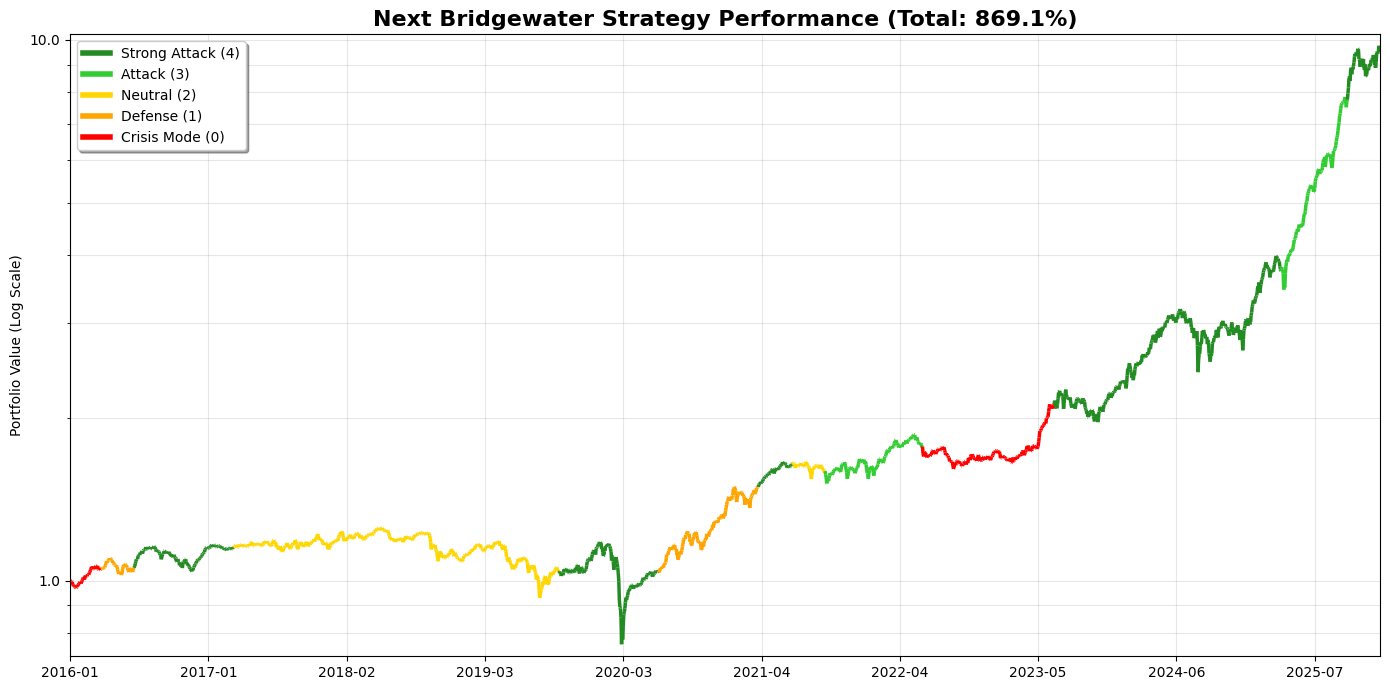


모든 프로세스가 성공적으로 완료되었습니다.


In [500]:
if __name__ == "__main__":
    print("\n" + "="*50)
    print("백테스팅 시작")
    print("="*50)

    # -----------------------------------------------------
    # 1. 데이터 준비 단계 (Data Preparation)
    # -----------------------------------------------------

    # 1-1. 공격 자산 (Top 30 유니버스)
    target_universe = get_universe_from_csv()

    if target_universe:
        agg_ret = calculate_aggressive_strategy(target_universe)
    else:
        print("경고: 유니버스가 비어있습니다.")
        agg_ret = pd.Series()

    # 1-2. 방어 자산 (ETF)
    def_ret = calculate_defensive_strategy()

    # 1-3. 카나리아 신호 (Market Signal)
    canary_signals = get_historical_canary_signals()

    # -----------------------------------------------------
    # 2. 전략 실행 단계 (Execution)
    # -----------------------------------------------------

    # 필수 데이터가 모두 존재하는지 확인
    if not agg_ret.empty and not def_ret.empty and canary_signals is not None:

        # 2-1. 백테스트 엔진 가동
        # (공격 수익률, 방어 수익률, 카나리아 신호를 섞어서 최종 포트폴리오 수익률 산출)
        port_ret, weights = run_backtest(agg_ret, def_ret, canary_signals)

        # 2-2. 성과 분석 (CAGR, MDD 등 계산 및 출력)
        metrics, wealth_index, drawdown = evaluate_performance(port_ret)

        # -------------------------------------------------
        # 3. 시각화 단계 (Visualization)
        # -------------------------------------------------

        # 카나리아 국면별 컬러 그래프 그리기
        # (이 함수 안에 파일 저장 로직이 포함되어 있습니다)
        plot_canary_visualization(port_ret, canary_signals)

        print("\n모든 프로세스가 성공적으로 완료되었습니다.")

    else:
        print("\n[오류] 데이터 부족으로 백테스팅을 수행할 수 없습니다.")
        print(f"   - 공격자산 데이터 유무: {not agg_ret.empty}")
        print(f"   - 방어자산 데이터 유무: {not def_ret.empty}")
        print(f"   - 카나리아 신호 유무: {canary_signals is not None}")